In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_style("whitegrid")

In [2]:
from pathlib import Path

project_root = Path.cwd().parent

data_path = project_root / "data" / "raw"

fund_master = pd.read_csv(data_path/"01_fund_master.csv")
nav = pd.read_csv(data_path/"02_nav_history.csv")
aum = pd.read_csv(data_path/"03_aum_by_fund_house.csv")
sip = pd.read_csv(data_path/"04_monthly_sip_inflows.csv")
category = pd.read_csv(data_path/"05_category_inflows.csv")
folio = pd.read_csv(data_path/"06_industry_folio_count.csv")
performance = pd.read_csv(data_path/"07_scheme_performance.csv")
transactions = pd.read_csv(data_path/"08_investor_transactions.csv")
portfolio = pd.read_csv(data_path/"09_portfolio_holdings.csv")

In [3]:
print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)


# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Merge scheme names
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

# Plot
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trends of 40 Mutual Fund Schemes (2022–2025)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run"
)

# Highlight 2024 Correction
fig.add_vrect(
    x0="2024-06-01",
    x1="2024-09-30",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction"
)

fig.show()

In [6]:
from pathlib import Path
reports_path = Path.cwd().parent / "reports"
fig.write_image(reports_path / "nav_trend.png")

/Users/sankalp/SRS (UNSYNCED)/Work/Jupyter/bluestock_mf_capstone/reports


# AUM Growth by Fund House

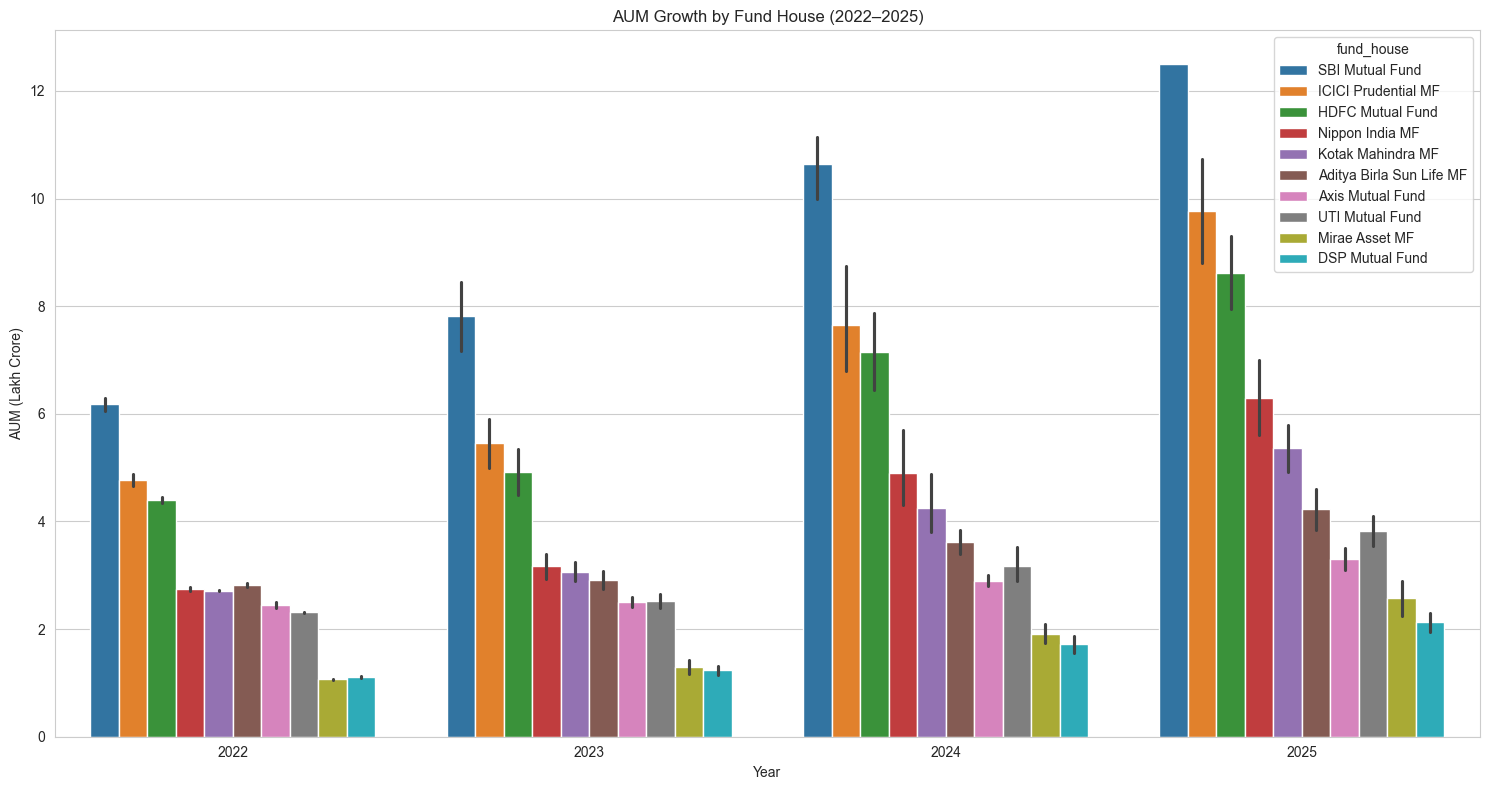

In [7]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year
plt.figure(figsize=(15,8))
sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.tight_layout()
plt.savefig(reports_path / "aum_growth.png")
plt.show()

# Monthly SIP Inflow Trend (2022–2025)

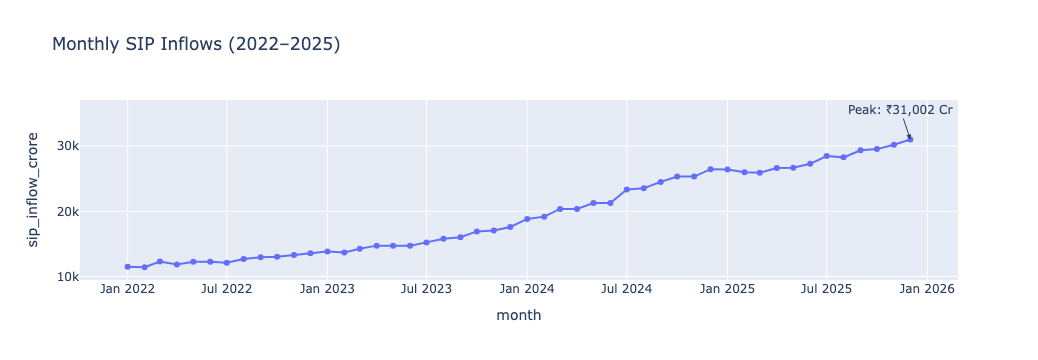

Highest SIP Inflow:
month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [14]:
# SIP Inflow Trend Analysis

sip["month"] = pd.to_datetime(sip["month"])

peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022–2025)"
)

fig.add_annotation(
    x=peak["month"].strftime("%Y-%m-%d"),
    y=float(peak["sip_inflow_crore"]),
    text=f"Peak: ₹{peak['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

fig.write_image(reports_path / "sip_trend.png")

print("Highest SIP Inflow:")
print(peak)

# Category Inflow Heatmap

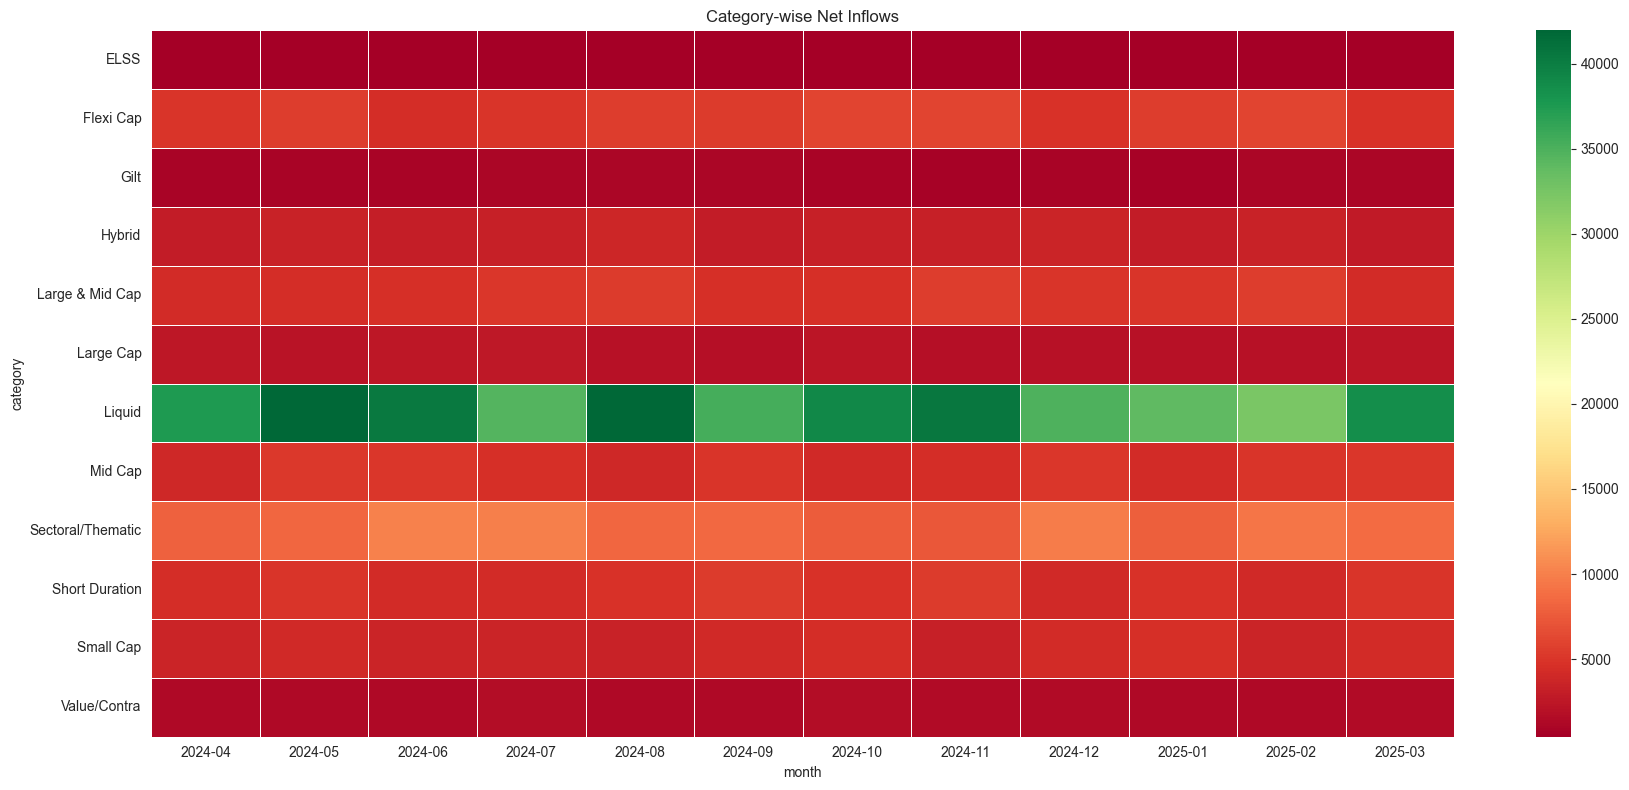

In [13]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(18,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Category-wise Net Inflows")

plt.tight_layout()

plt.savefig(reports_path / "category_heatmap.png")

plt.show()

# Investor Age Group Distribution

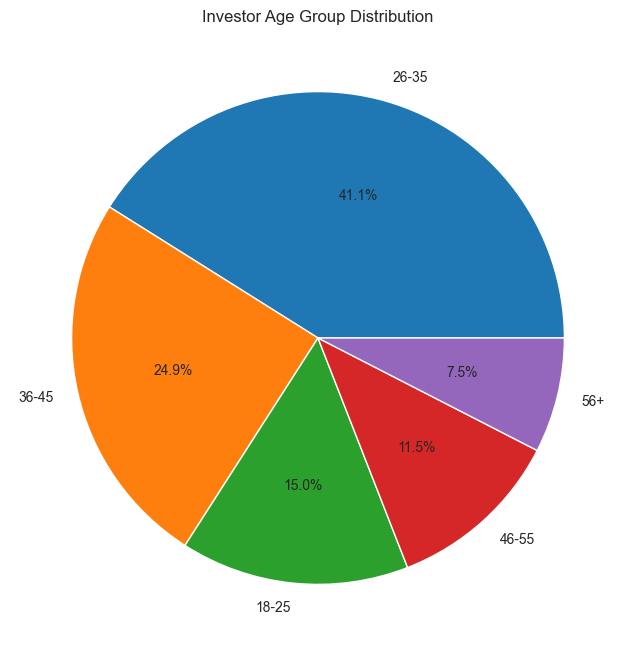

In [15]:
transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Investor Age Group Distribution")

plt.savefig(reports_path / "age_distribution.png")

plt.show()

# Gender Distribution of Investors

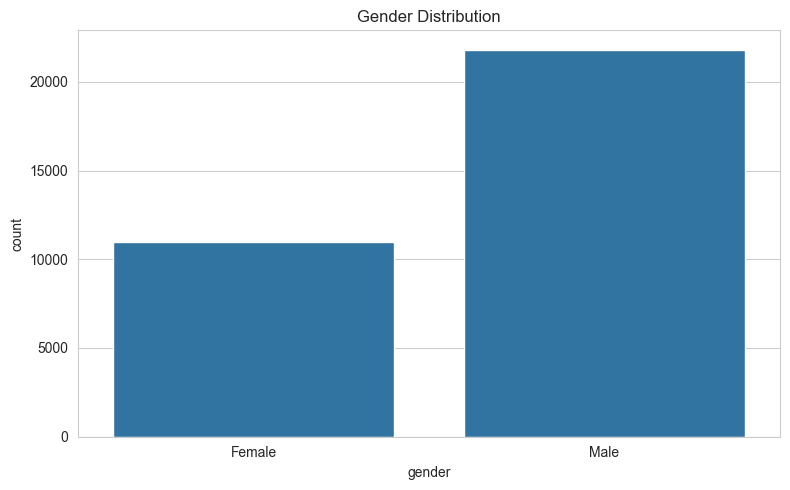

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution")

plt.tight_layout()

plt.savefig(reports_path / "gender_split.png")

plt.show()

# SIP Amount Distribution by Age Group

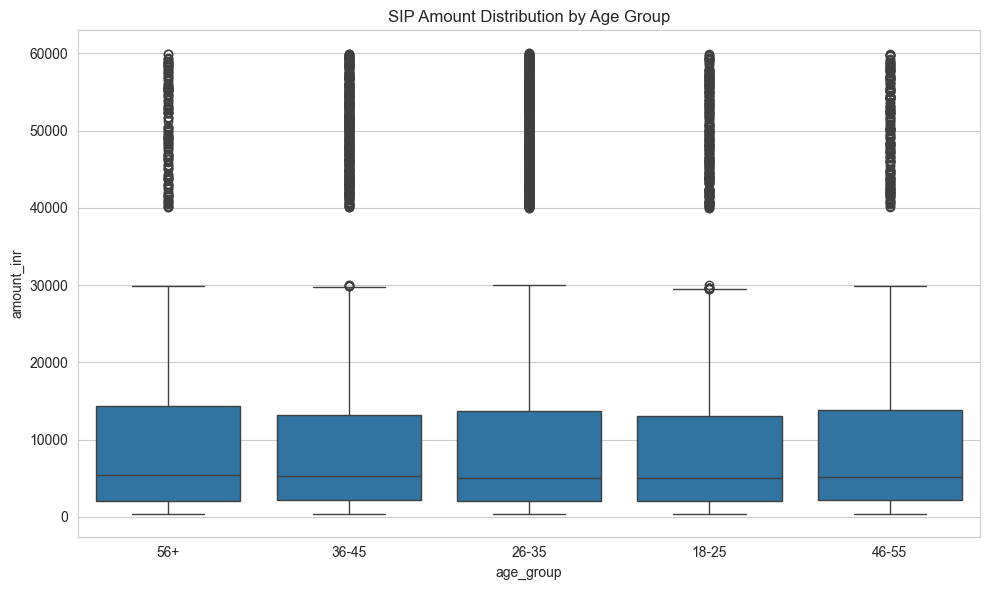

In [17]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.tight_layout()

plt.savefig(reports_path / "sip_boxplot.png")

plt.show()

# Geographic Distribution of SIP Investments

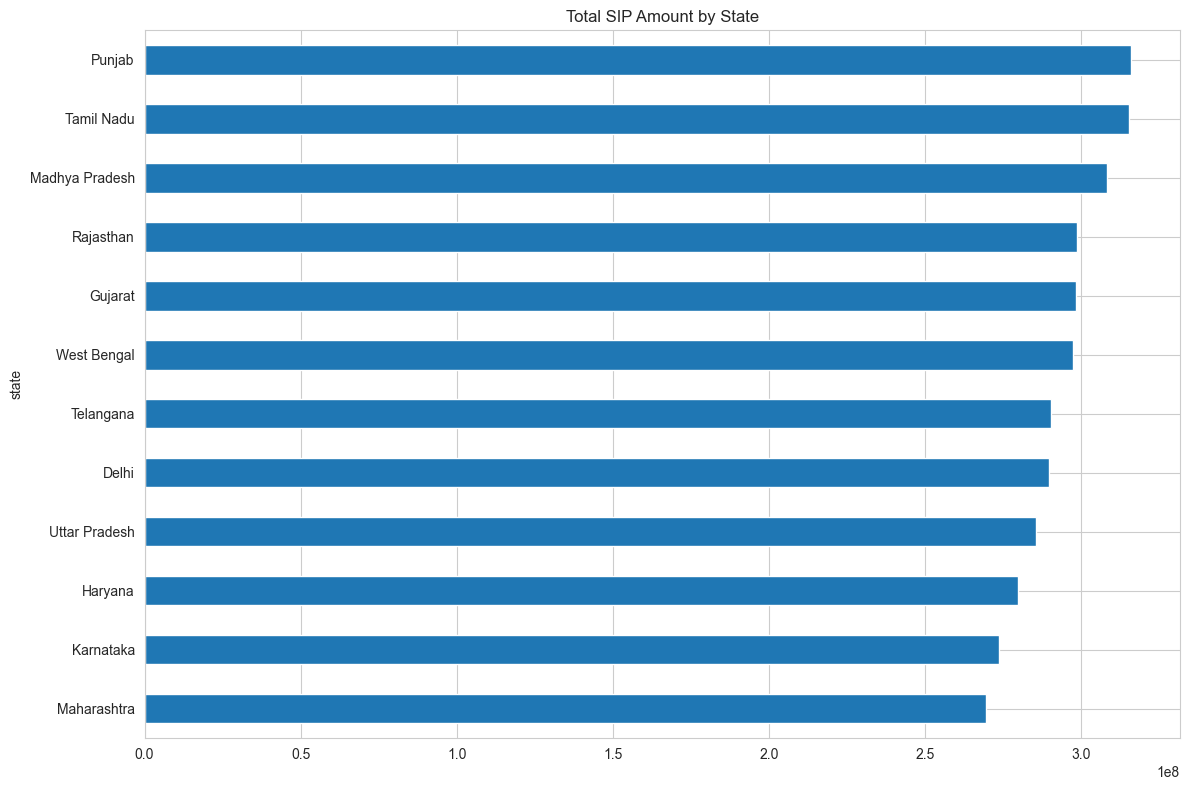

In [18]:
state_sip = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

state_sip.plot.barh()

plt.title("Total SIP Amount by State")

plt.tight_layout()

plt.savefig(reports_path / "state_sip.png")

plt.show()

# T30 vs B30 Investor Distribution

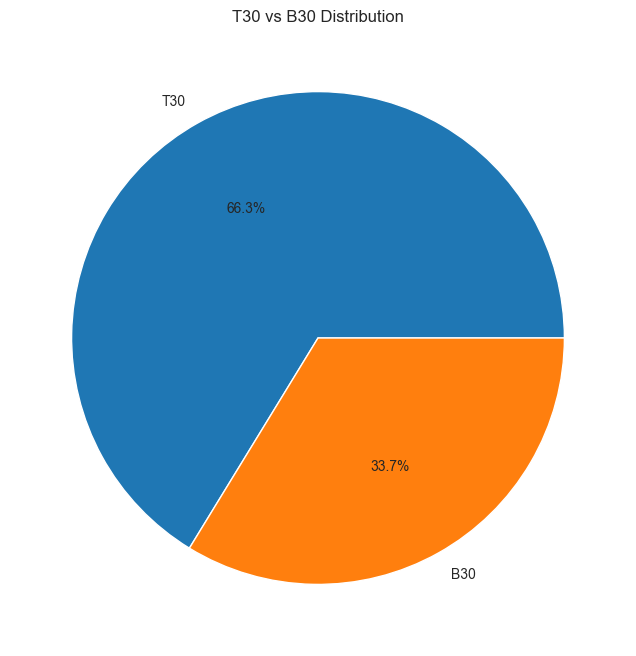

In [19]:
transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("T30 vs B30 Distribution")

plt.ylabel("")

plt.savefig(reports_path / "t30_b30.png")

plt.show()

# Industry Folio Growth

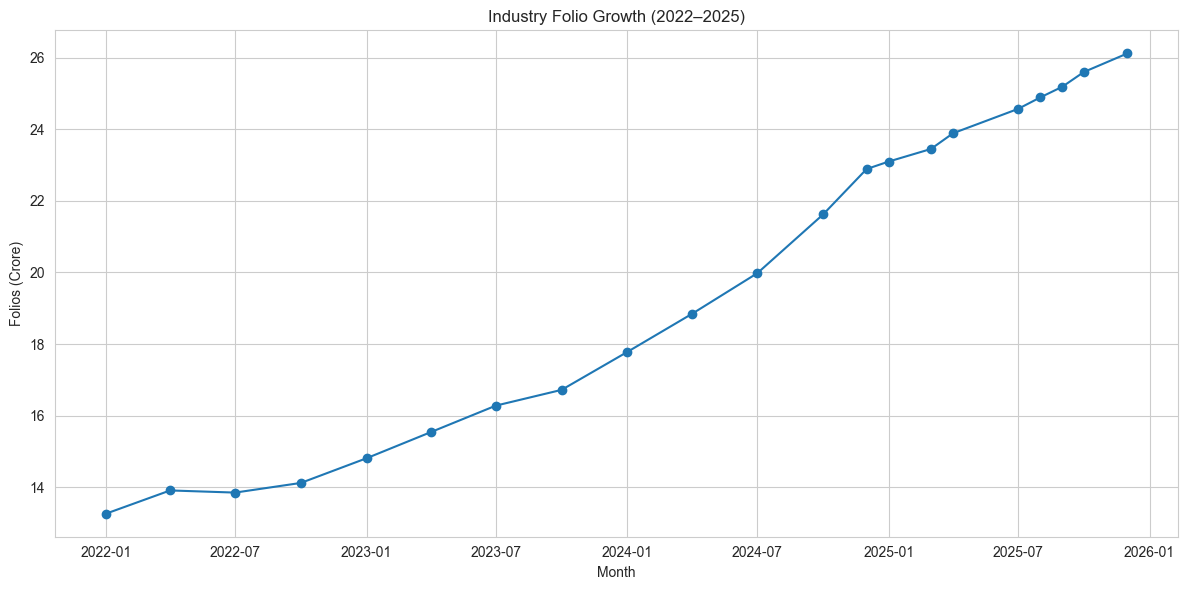

In [20]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(reports_path / "folio_growth.png")

plt.show()

# Correlation Matrix of Daily Fund Returns

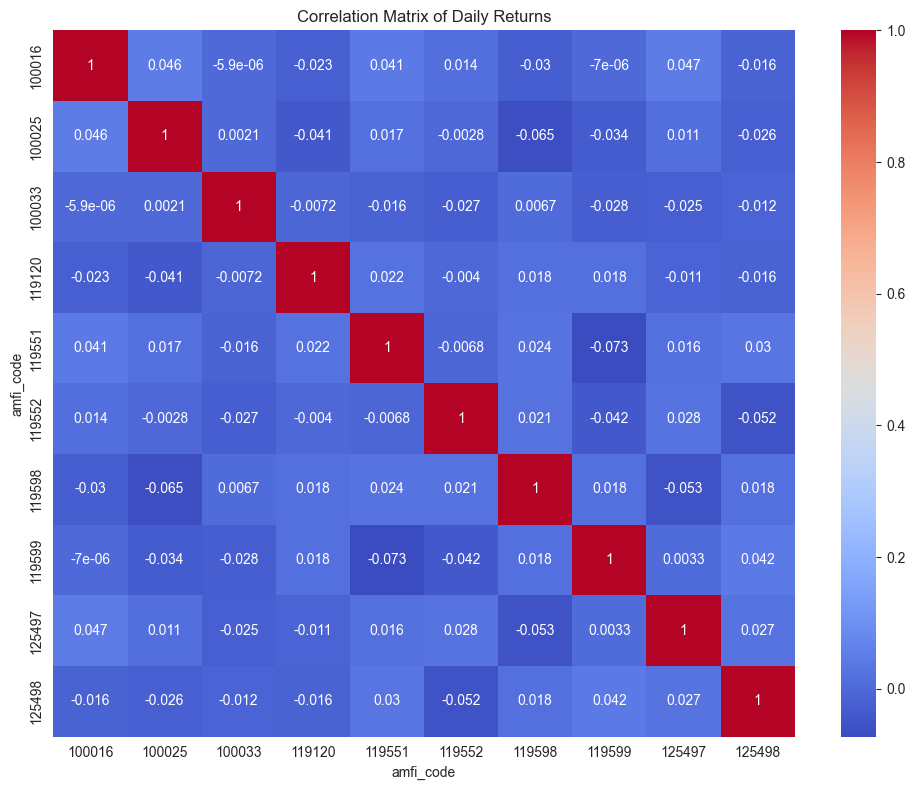

In [21]:
nav["date"] = pd.to_datetime(nav["date"])

selected_funds = nav["amfi_code"].unique()[:10]

corr_data = nav[
    nav["amfi_code"].isin(selected_funds)
]

pivot = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Daily Returns")

plt.tight_layout()

plt.savefig(reports_path / "correlation_matrix.png")

plt.show()

# Sector Allocation Across Equity Funds

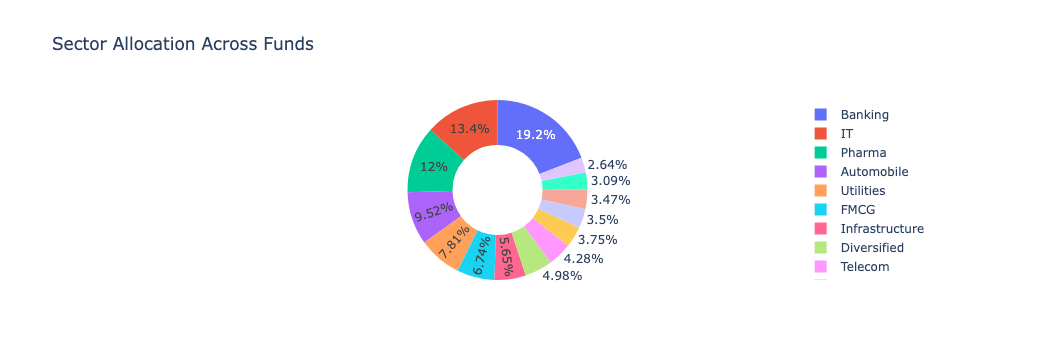

In [22]:
sector_weights = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sector_weights,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation Across Funds"
)

fig.show()

fig.write_image(
    reports_path / "sector_donut.png"
)